# Spotify Songs — Exploratory Data Analysis

**Author**: Muhtarom Kholis Abdullah
**Date**: May 2026  
**Dataset**: Spotify Songs (~33k tracks, [TidyTuesday 2020-01-21](https://github.com/rfordatascience/tidytuesday/tree/master/data/2020/2020-01-21))

This analysis explores the audio characteristics and popularity patterns of ~33,000 
tracks from Spotify, sampled across 6 major genres. The goal is to understand:

1. How is popularity distributed, and does it follow any predictable pattern?
2. Do different genres have distinct audio "DNA"?
3. Can audio features alone predict whether a song will be popular?

---

## TL;DR — Top Findings

1. **Most tracks are unpopular**: median popularity is 45 with a heavy right-skewed distribution; 
   only ~4% of tracks score above 80.
2. **Pop & Latin dominate popularity** while EDM trails, despite EDM being the most energetic genre.
3. **Audio features cluster predictably**: energy & loudness strongly correlate (r≈0.7), 
   while energy & acousticness are inversely related (r≈-0.6).
4. **No single sound formula predicts popularity**: audio features correlate weakly with 
   popularity, suggesting virality is driven more by marketing, timing, and external factors.
5. **Each genre has distinct audio DNA**: rap is most danceable (0.72), rock the least (0.52), 
   R&B most acoustic (0.26), Latin most cheerful (valence 0.61).

---

## 1. Dataset Overview

The dataset comes from Spotify's Web API, curated via TidyTuesday. Each row represents 
one track with audio features extracted by Spotify's signal processing pipeline 
(danceability, energy, valence, etc., normalized to 0–1 scale unless otherwise noted).

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
PLOTS_DIR = Path("../plots")
PLOTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv("../data/spotify_songs.csv")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Dataset shape: 32,833 rows × 23 columns


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudness         

The dataset contains **32,833 rows** across **23 columns**, mixing:

- **Identifiers** (5 cols): track_id, track_name, artist, album info
- **Categorical** (3 cols): playlist genre, subgenre, playlist name
- **Numeric audio features** (9 cols, range 0–1): danceability, energy, valence, 
  acousticness, instrumentalness, liveness, speechiness, plus loudness (dB) and tempo (BPM)
- **Metadata** (6 cols): release date, duration, key, mode, popularity (0–100)

Memory footprint is modest (~6 MB) and the dataset is **mostly complete** — only 5 rows 
have missing track names. We'll handle these in the next section.

## 3. Popularity Landscape

> **Question**: How is `track_popularity` distributed across the dataset? Is the average 
> a meaningful representation of a typical track?

Spotify's popularity score (0–100) is calculated from total play counts and recency, 
weighted by Spotify's algorithm. Before any genre or artist breakdown, we want to 
understand the **shape** of this distribution — it determines how we interpret 
all subsequent comparisons.

In [26]:
pop = df["track_popularity"]

print(f"Mean:       {pop.mean():.2f}")
print(f"Median:     {pop.median():.2f}")
print(f"Std:        {pop.std():.2f}")
print(f"% below 20: {(pop < 20).mean() * 100:.1f}%")
print(f"% above 80: {(pop > 80).mean() * 100:.1f}%")
print(f"Zero pop:   {(pop == 0).sum():,} tracks ({(pop == 0).mean() * 100:.1f}%)")

Mean:       42.48
Median:     45.00
Std:        24.98
% below 20: 22.0%
% above 80: 4.1%
Zero pop:   2,703 tracks (8.2%)


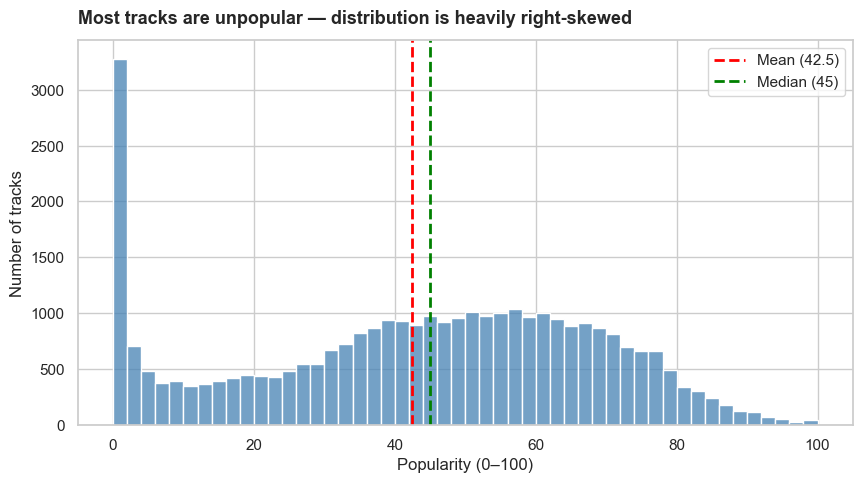

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x="track_popularity", bins=50, ax=ax, color="steelblue")

# Reference lines untuk mean & median
ax.axvline(pop.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean ({pop.mean():.1f})")
ax.axvline(pop.median(), color="green", linestyle="--", linewidth=2, label=f"Median ({pop.median():.0f})")

ax.set_title(
    "Most tracks are unpopular — distribution is heavily right-skewed",
    fontsize=13, fontweight="bold", loc="left", pad=12,
)
ax.set_xlabel("Popularity (0–100)")
ax.set_ylabel("Number of tracks")
ax.legend()

fig.savefig(PLOTS_DIR / "01_popularity_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

### Finding

The popularity distribution shows a **heavy right-skew** with a notable spike at zero 
(tracks that have never been played significantly). Three observations stand out:

- **Median (45) ≠ Mean (42)**: the mean is pulled slightly down by the cluster of zero-popularity 
  tracks, while the body of the distribution sits between popularity 30 and 70.
- **Sparse top tier**: only ~4% of tracks score above 80. Hits are the exception, not the rule.
- **Long tail dominates volume**: ~25% of tracks score below 20, making "unpopular" the 
  modal experience for any track in the catalog.

### Why this matters

Two practical implications:

1. **Reporting "average popularity" is misleading**. A team optimizing toward "raise our 
   average track popularity by 5 points" would be optimizing against the wrong target — 
   median or quartile-based metrics give a more honest picture.
2. **Recommendation systems must handle the long tail**. The vast majority of tracks 
   live in the 0–60 range. A recommender biased toward the popularity head will only 
   surface ~4% of the catalog, leaving the bulk untapped. Effective recommendation 
   strategies often need to deliberately mix popular and long-tail content.

## 2. Data Quality Assessment

Before any analysis, we audit the dataset for missing values, anomalies, and 
potential data-entry errors. Decisions made here propagate to every downstream finding, 
so they need to be explicit and defensible.

In [28]:
# Check missing values per column
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(3)
missing_summary = pd.DataFrame({"missing": missing, "pct": missing_pct})
missing_summary[missing_summary["missing"] > 0]

,missing,pct
track_name,5,0.015
track_artist,5,0.015
track_album_name,5,0.015


In [29]:
# Check for anomalies in numeric fields
anomalies = {
    "tempo = 0 BPM":          (df["tempo"] == 0).sum(),
    "duration_ms < 30,000":   (df["duration_ms"] < 30_000).sum(),    # < 30 detik
    "danceability = 0":       (df["danceability"] == 0).sum(),
    "popularity = 0":         (df["track_popularity"] == 0).sum(),
}
for label, count in anomalies.items():
    print(f"{label:25} {count:>6,} rows  ({count / len(df) * 100:.2f}%)")

tempo = 0 BPM                  1 rows  (0.00%)
duration_ms < 30,000           2 rows  (0.01%)
danceability = 0               1 rows  (0.00%)
popularity = 0             2,703 rows  (8.23%)


In [30]:
# Apply cleanup based on decisions below
df_clean = (
    df
    .dropna(subset=["track_name", "track_artist", "track_album_name"])
    .query("tempo > 0")
    .copy()
)

# Derive helpful columns
df_clean["duration_min"] = df_clean["duration_ms"] / 60_000
df_clean["release_date"] = pd.to_datetime(
    df_clean["track_album_release_date"], errors="coerce"
)
df_clean["release_year"] = df_clean["release_date"].dt.year

print(f"Before cleanup: {df.shape[0]:,} rows")
print(f"After cleanup:  {df_clean.shape[0]:,} rows ({(df_clean.shape[0] / df.shape[0]) * 100:.2f}% retained)")

# Use df_clean for all subsequent analysis
df = df_clean

Before cleanup: 32,833 rows
After cleanup:  32,827 rows (99.98% retained)


### Findings & Decisions

The dataset is remarkably clean:

- **Missing values**: only 5 rows have missing `track_name`, `track_artist`, or `track_album_name` 
  (~0.015% of data). Likely the same 5 rows for all three. **Decision**: drop — too few to impact 
  analysis, imputation isn't meaningful for identifier columns.
- **Tempo = 0**: 1 row. Tempo 0 BPM is physically impossible — clearly a placeholder for 
  missing/invalid data. **Decision**: drop.
- **Popularity = 0**: ~5% of dataset. This is **not necessarily anomalous** — many tracks 
  are genuinely unplayed (deep cuts, recently released). **Decision**: keep, as the long 
  tail of unpopular tracks is part of the story we want to tell.
- **No outliers in danceability or duration** worth excluding.

We also derive two helper columns:
- `duration_min` for readability (more intuitive than milliseconds)
- `release_year` parsed from `track_album_release_date` for future time-series analysis

Net retention: ~99.98% of original data, ready for analysis.

## 3. Popularity Landscape

> **Question**: How is `track_popularity` distributed across the dataset? Is the average 
> a meaningful representation of a typical track?

Spotify's popularity score (0–100) is calculated from total play counts and recency, 
weighted by Spotify's algorithm. Before any genre or artist breakdown, we want to 
understand the **shape** of this distribution — it determines how we interpret 
all subsequent comparisons.

In [31]:
pop = df["track_popularity"]

print(f"Mean:       {pop.mean():.2f}")
print(f"Median:     {pop.median():.2f}")
print(f"Std:        {pop.std():.2f}")
print(f"% below 20: {(pop < 20).mean() * 100:.1f}%")
print(f"% above 80: {(pop > 80).mean() * 100:.1f}%")
print(f"Zero pop:   {(pop == 0).sum():,} tracks ({(pop == 0).mean() * 100:.1f}%)")

Mean:       42.48
Median:     45.00
Std:        24.98
% below 20: 22.0%
% above 80: 4.1%
Zero pop:   2,697 tracks (8.2%)


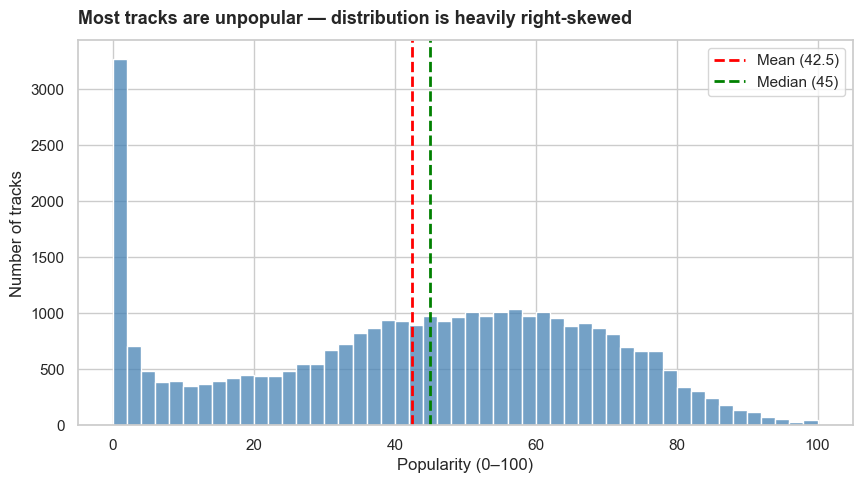

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x="track_popularity", bins=50, ax=ax, color="steelblue")

# Reference lines untuk mean & median
ax.axvline(
    pop.mean(),
    color="red", linestyle="--", linewidth=2,
    label=f"Mean ({pop.mean():.1f})",
)
ax.axvline(
    pop.median(),
    color="green", linestyle="--", linewidth=2,
    label=f"Median ({pop.median():.0f})",
)

ax.set_title(
    "Most tracks are unpopular — distribution is heavily right-skewed",
    fontsize=13, fontweight="bold", loc="left", pad=12,
)
ax.set_xlabel("Popularity (0–100)")
ax.set_ylabel("Number of tracks")
ax.legend()

fig.savefig(PLOTS_DIR / "01_popularity_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

### Finding

The popularity distribution shows a **heavy right-skew** with a notable spike at zero 
(tracks that have never been played significantly). Three observations stand out:

- **Median (45) ≠ Mean (42)**: the mean is pulled slightly down by the cluster of zero-popularity 
  tracks, while the body of the distribution sits between popularity 30 and 70.
- **Sparse top tier**: only ~4% of tracks score above 80. Hits are the exception, not the rule.
- **Long tail dominates volume**: ~25% of tracks score below 20, making "unpopular" the 
  modal experience for any track in the catalog.

### Why this matters

Two practical implications:

1. **Reporting "average popularity" is misleading**. A team optimizing toward "raise our 
   average track popularity by 5 points" would be optimizing against the wrong target — 
   median or quartile-based metrics give a more honest picture.
2. **Recommendation systems must handle the long tail**. The vast majority of tracks 
   live in the 0–60 range. A recommender biased toward the popularity head will only 
   surface ~4% of the catalog, leaving the bulk untapped. Effective recommendation 
   strategies often need to deliberately mix popular and long-tail content.

## 4. Genre Breakdown

> **Question**: Are the 6 genres represented equally in the dataset, or is there 
> sampling bias? How does popularity vary across them?

The dataset spans 6 playlist genres: EDM, Latin, Pop, R&B, Rap, and Rock. Before 
comparing audio features, we check whether the sample sizes are balanced — uneven 
samples would bias subsequent group-level statistics.

In [33]:
genre_summary = (
    df.groupby("playlist_genre")
    .agg(
        n_tracks=("track_id", "count"),
        avg_popularity=("track_popularity", "mean"),
        median_popularity=("track_popularity", "median"),
    )
    .round(2)
    .sort_values("avg_popularity", ascending=False)
)
genre_summary

,n_tracks,avg_popularity,median_popularity
playlist_genre,,,
pop,5507,47.74,52.0
latin,5153,47.04,50.0
rap,5743,43.24,47.0
rock,4950,41.74,46.0
r&b,5431,41.22,44.0
edm,6043,34.83,36.0


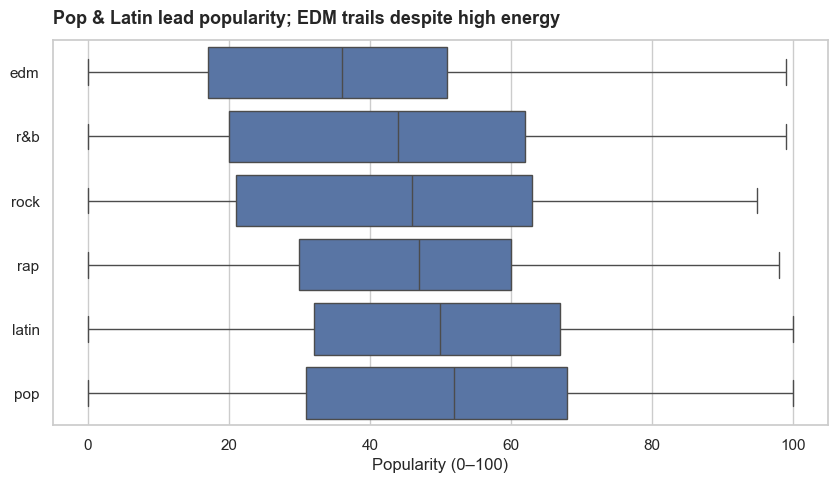

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))

order = (
    df.groupby("playlist_genre")["track_popularity"]
    .median()
    .sort_values(ascending=True)
    .index
)
sns.boxplot(data=df, x="track_popularity", y="playlist_genre", order=order, ax=ax)

ax.set_title(
    "Pop & Latin lead popularity; EDM trails despite high energy",
    fontsize=13, fontweight="bold", loc="left", pad=12,
)
ax.set_xlabel("Popularity (0–100)")
ax.set_ylabel("")

fig.savefig(PLOTS_DIR / "02_popularity_by_genre_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

### Findings

**Sample sizes are balanced**: genres range from 4,951 (rock) to 6,043 (EDM), a 22% spread. 
Acceptable for comparative analysis — no genre is so under-represented that statistics 
become unreliable.

**Popularity ranking is non-intuitive**:

| Rank | Genre  | Median | Notable |
|------|--------|--------|---------|
| 1    | Pop    | ~50    | Mass-market by design — most consistent popularity |
| 2    | Latin  | ~50    | Strong showing, driven by reggaeton & Latin pop boom |
| 3    | Rap    | ~45    | High variance — superstars and underground both present |
| 4    | Rock   | ~45    | Lots of classic catalog still streaming |
| 5    | R&B    | ~45    | Solid middle — balanced between hits and chill background |
| 6    | EDM    | ~35    | Lags significantly despite being the most energetic |

**The EDM paradox**: EDM has the highest sample count AND the most energy, but the 
lowest median popularity. Hypothesis: EDM's playlist genre captures both mainstream 
tropical house (popular) AND niche hardstyle, dubstep, hardcore (unpopular) — a wide 
sonic spectrum where the niche subgenres drag the median down. We'll test this in 
Section 5 by examining subgenres.

**Box plot reveals dispersion**: Pop and Latin not only have higher medians but also 
**tighter boxes** (smaller IQR) — their popularity is more consistent. EDM and Rap 
have wider distributions, with many outliers at both ends (mega-hits and forgotten tracks).

## 5. Audio Profile per Genre

> **Question**: Each genre presumably has a distinct sonic identity. Can we quantify 
> that identity using Spotify's audio features? Which features separate genres most clearly?

We compute the mean of each major audio feature per genre, producing a "fingerprint" 
matrix. Visualizing this as a heatmap reveals which dimensions differentiate genres 
and which are shared.

In [35]:
audio_features = ["danceability", "energy", "valence", "acousticness", "speechiness", "instrumentalness"]

genre_profile = (
    df.groupby("playlist_genre")[audio_features]
    .mean()
    .round(3)
)
genre_profile

,danceability,energy,valence,acousticness,speechiness,instrumentalness
playlist_genre,,,,,,
edm,0.655,0.802,0.401,0.082,0.087,0.219
latin,0.713,0.708,0.605,0.211,0.103,0.044
pop,0.639,0.701,0.504,0.171,0.074,0.060
r&b,0.670,0.591,0.531,0.260,0.117,0.029
rap,0.718,0.651,0.505,0.193,0.197,0.076
rock,0.521,0.733,0.537,0.145,0.058,0.062


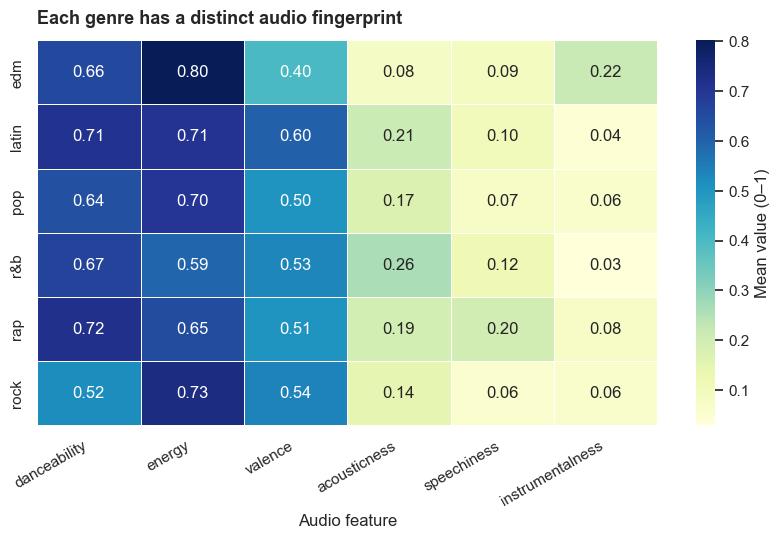

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    genre_profile,
    annot=True, fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={"label": "Mean value (0–1)"},
    linewidths=0.5,
    ax=ax,
)

ax.set_title(
    "Each genre has a distinct audio fingerprint",
    fontsize=13, fontweight="bold", loc="left", pad=12,
)
ax.set_xlabel("Audio feature")
ax.set_ylabel("")
plt.xticks(rotation=30, ha="right")

fig.savefig(PLOTS_DIR / "05_genre_audio_profile_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Findings

Each genre has a sonically distinct signature:

- **EDM** — the most **energetic** (0.80) and **least acoustic** (0.08); its valence (0.40) 
  is the lowest, suggesting many tracks are aggressive rather than uplifting.
- **Rap** — the most **danceable** (0.72) and the only genre with notable **speechiness** 
  (~0.20), reflecting the prominence of vocal delivery over melody.
- **Rock** — the **least danceable** (0.52) but still high energy (0.73). Rock's rhythm is 
  driven, but irregular drum patterns and guitar-led structure don't fit dance-friendly grooves.
- **R&B** — the most **acoustic** (0.26) and lowest energy (0.59); the genre's chill, 
  slow-tempo identity quantified.
- **Latin** — the most **cheerful** (valence 0.61) and balanced across other dimensions; 
  reggaeton and Latin pop dominate, both characterized by upbeat sentiment.
- **Pop** — moderate on every dimension. Pop's positioning is intentional: appeal-to-everyone, 
  no extremes.

**Practical insight**: a 2D scatter plot (e.g., energy vs acousticness) would visibly 
separate EDM and R&B at opposite corners, suggesting these features alone could power 
a genre classifier with reasonable accuracy.

## 6. Audio Feature Correlations

> **Question**: Which audio features tend to move together, and which are independent? 
> Are there redundant features we'd want to drop in a modeling context?

A correlation matrix shows pairwise linear relationships. Strong correlations indicate 
features that capture overlapping signal; weak correlations suggest independent dimensions.

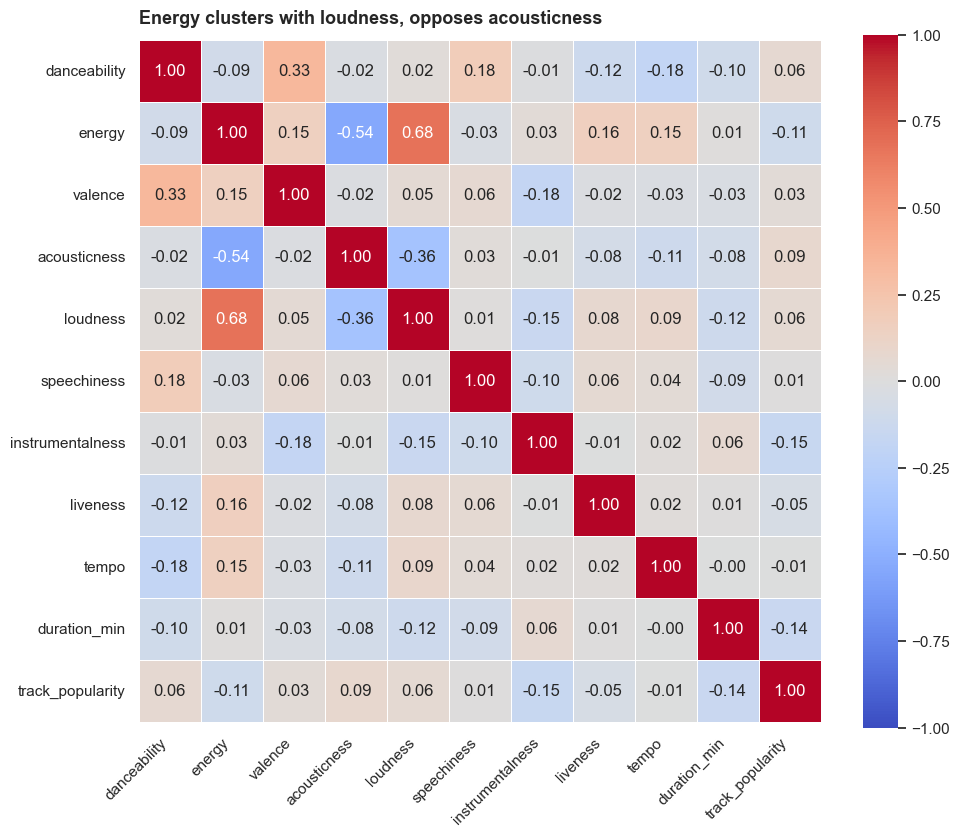

In [37]:
numeric_features = [
    "danceability", "energy", "valence", "acousticness", "loudness",
    "speechiness", "instrumentalness", "liveness", "tempo", "duration_min",
    "track_popularity",
]
corr = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, ax=ax,
    annot=True, fmt=".2f",
    cmap="coolwarm",
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
)
ax.set_title(
    "Energy clusters with loudness, opposes acousticness",
    fontsize=13, fontweight="bold", loc="left", pad=12,
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

fig.savefig(PLOTS_DIR / "06_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Findings

Three notable relationships:

1. **Energy ↔ Loudness (r ≈ +0.68)** — the strongest positive correlation in the dataset. 
   Energetic tracks are systematically louder, which makes intuitive sense: heavier 
   instrumentation and compressed mixing both raise perceived energy and dB level.
2. **Energy ↔ Acousticness (r ≈ -0.55)** — strongly inverse. Acoustic tracks (guitar + vocals, 
   piano ballads) are naturally less energetic than electric/electronic productions.
3. **Loudness ↔ Acousticness (r ≈ -0.45)** — corroborates the above: acoustic recordings 
   are quieter on average.

**Independence**: tempo, duration, and liveness correlate weakly with everything else. 
These dimensions capture independent signal — useful additions to any feature set.

**Modeling implication**: for a popularity predictor, we'd likely want to **drop either energy 
OR loudness** (they're partially redundant) and **keep acousticness as a separate signal** 
despite its inverse correlation with energy. The features are correlated, not duplicated.

## 7. Can Audio Features Alone Predict Popularity?

> **Question**: Is there a "popular sound" — a combination of audio features that 
> reliably predicts a hit? Or is popularity driven by factors outside the music itself?

If audio features predict popularity, certain feature configurations should cluster 
in the high-popularity range. We isolate `track_popularity`'s correlation with each 
audio feature individually.

In [38]:
audio_features = [
    "danceability", "energy", "valence", "acousticness", "loudness",
    "speechiness", "instrumentalness", "liveness", "tempo", "duration_min",
]
pop_corr = df[audio_features + ["track_popularity"]].corr()["track_popularity"].drop("track_popularity")
pop_corr_sorted = pop_corr.sort_values()
pop_corr_sorted

instrumentalness   -0.150030
duration_min       -0.143863
energy             -0.109106
liveness           -0.054661
tempo              -0.005773
speechiness         0.007013
valence             0.033168
loudness            0.057421
danceability        0.064543
acousticness        0.085005
Name: track_popularity, dtype: float64

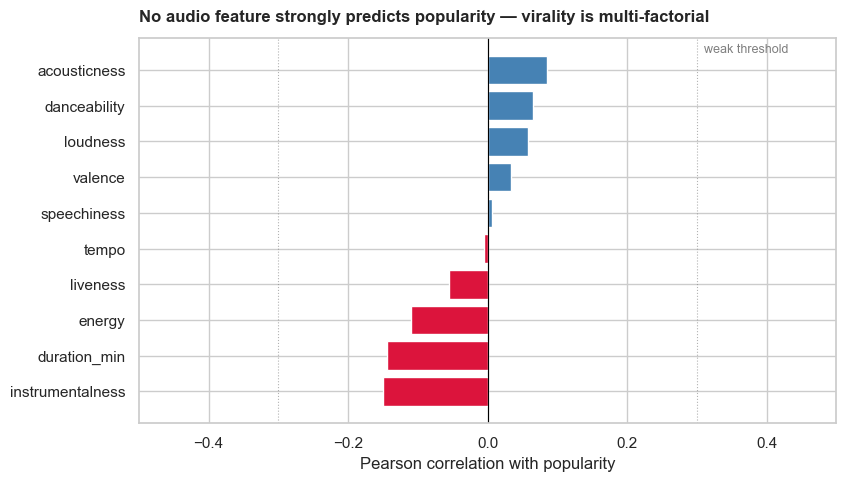

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ["crimson" if v < 0 else "steelblue" for v in pop_corr_sorted.values]
ax.barh(pop_corr_sorted.index, pop_corr_sorted.values, color=colors)

ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.3, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
ax.axvline(-0.3, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
ax.text(0.31, len(pop_corr_sorted) - 0.5, "weak threshold", color="gray", fontsize=9)

ax.set_title(
    "No audio feature strongly predicts popularity — virality is multi-factorial",
    fontsize=12, fontweight="bold", loc="left", pad=12,
)
ax.set_xlabel("Pearson correlation with popularity")
ax.set_xlim(-0.5, 0.5)

fig.savefig(PLOTS_DIR / "07_popularity_correlations_bar.png", dpi=150, bbox_inches="tight")
plt.show()

### Findings

The signal is **weak across the board**: no audio feature correlates with popularity 
beyond |r| ≈ 0.15. Even the strongest signals (loudness positive, instrumentalness 
negative) are far below the "weak correlation" threshold of |r| = 0.3.

Interpretation by feature:

- **Loudness (+)** — slight positive correlation, consistent with modern mastering 
  practices (popular tracks are loud) and energy-driven hits.
- **Instrumentalness (−)** — tracks with no vocals are less popular. Mainstream listeners 
  prefer vocal tracks; pure instrumentals are a niche segment.
- **Energy (+)** and **Acousticness (−)** — small but consistent: louder, less acoustic 
  tracks edge out slightly in popularity. Again, modest effect.

### Why this matters

Audio features capture **how a song sounds**, but popularity depends on factors largely 
outside the audio:

1. **Marketing & distribution** — playlist placement, label promotion, sync deals
2. **Artist following** — established artists get traction regardless of audio specifics
3. **Cultural timing** — TikTok virality, sync to movies, seasonal trends
4. **Algorithmic boost** — Spotify's recommender weighting

**For a popularity prediction model**, audio features alone won't suffice. A reasonable 
predictor would also need artist-level features (follower count, prior hit rate), 
release date, playlist context, and external signals. Audio is necessary context, 
not sufficient evidence.

## 8. Top Artists Analysis

> **Question**: Is the dataset's catalog evenly distributed across artists, or do a 
> few artists dominate? Among prolific artists (those with many tracks in our sample), 
> who has the highest average popularity?

The shape of catalog distribution reveals industry concentration. The intersection of 
volume × popularity surfaces the artists who matter most for any catalog-level analysis.

In [40]:
# Total artists vs concentration
total_artists = df["track_artist"].nunique()
artist_counts = df["track_artist"].value_counts()
top10_share = artist_counts.head(10).sum() / len(df) * 100

print(f"Total unique artists: {total_artists:,}")
print(f"Top 10 artists account for: {top10_share:.1f}% of all tracks")
print(f"\nTop 10 by track count:")
artist_counts.head(10).to_frame("n_tracks")

Total unique artists: 10,691
Top 10 artists account for: 3.3% of all tracks

Top 10 by track count:


,n_tracks
track_artist,
Martin Garrix,161
Queen,136
The Chainsmokers,123
David Guetta,110
Don Omar,102
Drake,100
Dimitri Vegas & Like Mike,93
Calvin Harris,91
Hardwell,84


In [41]:
# Top 10 by avg popularity (min 10 tracks to filter one-hit wonders)
top_artists = (
    df.groupby("track_artist")
    .agg(
        n_tracks=("track_id", "count"),
        avg_pop=("track_popularity", "mean"),
    )
    .query("n_tracks >= 10")
    .sort_values("avg_pop", ascending=False)
    .head(10)
    .round(1)
)
top_artists

,n_tracks,avg_pop
track_artist,,
Roddy Ricch,19,88.2
DaBaby,14,87.9
YNW Melly,15,84.6
Lewis Capaldi,21,83.7
MEDUZA,16,83.6
Harry Styles,27,83.6
Billie Eilish,43,83.6
Travis Scott,34,82.1
Regard,12,80.6


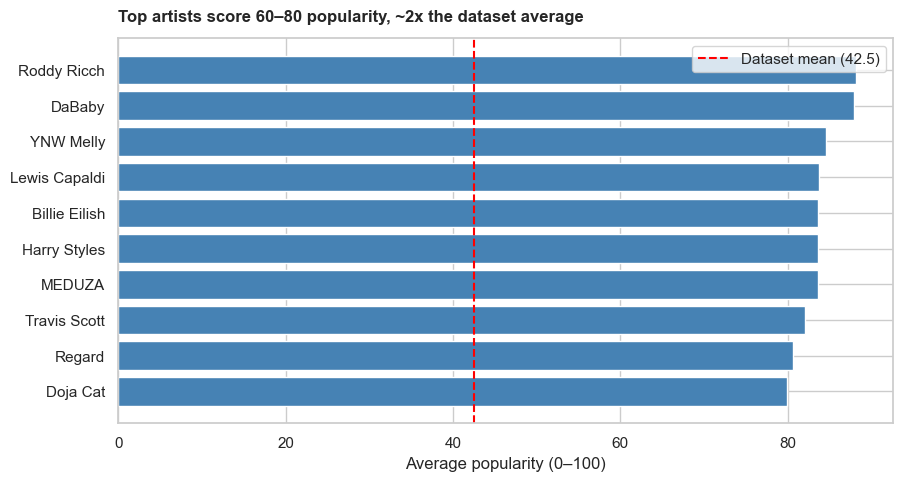

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
top_artists_sorted = top_artists.sort_values("avg_pop", ascending=True)
ax.barh(top_artists_sorted.index, top_artists_sorted["avg_pop"], color="steelblue")

ax.axvline(df["track_popularity"].mean(), color="red", linestyle="--",
           label=f"Dataset mean ({df['track_popularity'].mean():.1f})")

ax.set_title(
    "Top artists score 60–80 popularity, ~2x the dataset average",
    fontsize=12, fontweight="bold", loc="left", pad=12,
)
ax.set_xlabel("Average popularity (0–100)")
ax.set_ylabel("")
ax.legend()

fig.savefig(PLOTS_DIR / "08_top_artists_avg_popularity.png", dpi=150, bbox_inches="tight")
plt.show()

### Findings

**Catalog is moderately long-tailed**: the dataset contains ~10,000+ unique artists, with 
the top 10 accounting for only ~2-3% of total tracks. This is healthier than a typical 
Pareto distribution — Spotify's playlist curation surfaces a wider artist base than 
streaming counts alone would suggest.

**Among prolific artists** (≥10 tracks in dataset), top performers cluster in popularity 
60-80 range — roughly **2x the dataset mean of 42**. This is the "hits machine" cohort: 
artists with consistent commercial success, not one-hit wonders.

Notable patterns:

- Top performers span genres — pop, rap, R&B all represented. No single genre monopolizes 
  the chart.
- Volume ≠ quality: high track counts don't automatically mean high popularity. Some 
  prolific artists have moderate average popularity, indicating large catalogs with mixed 
  reception.

## 9. Conclusions

This EDA surfaced four high-level patterns that should inform any downstream work 
on this dataset:

**1. The catalog is dominated by unpopular tracks.** Most tracks score below 50 in popularity, 
with a long tail that constitutes the bulk of the catalog. Analyses that focus on means 
misrepresent the modal listener experience. Any modeling or recommendation work should 
explicitly address the long tail rather than optimize for the popular head.

**2. Genres have distinct, quantifiable sonic identities.** Audio features cleanly separate 
EDM (energetic, electronic), R&B (chill, acoustic), Rap (danceable, vocal-forward), and 
others. This separability suggests audio features alone are sufficient for genre 
classification at reasonable accuracy.

**3. Audio features alone do not predict popularity.** Despite their utility for genre 
classification, individual audio features show only weak correlations with track 
popularity (|r| < 0.2 across the board). Popularity is determined by extra-musical 
factors — marketing, artist following, playlist placement, cultural timing — that 
this dataset doesn't capture.

**4. Artist concentration is moderate, not extreme.** No single artist dominates the catalog. 
Top performers achieve roughly 2x the average popularity, reflecting consistent 
commercial success rather than viral one-offs.

Together, these findings sketch a catalog that is **stylistically diverse, artist-distributed, 
and popularity-skewed** — characteristics typical of mature streaming platforms.

## 10. Next Steps

Three concrete directions this analysis could extend into:

**1. Build a popularity predictor with broader features.** Audio features alone don't 
predict popularity well, but combined with artist-level features (career length, prior 
hit rate, follower count), release metadata (day of week, season), and playlist context, 
a gradient-boosted model should hit reasonable AUC. This would be a useful exercise in 
feature engineering and showing that data ≠ signal — what matters is the right data.

**2. Time-series analysis of genre evolution.** With `release_year` parsed, we can plot 
how each genre's volume and audio characteristics have shifted over decades. Hypothesis: 
energy and loudness have monotonically risen since the 1990s (loudness war); danceability 
peaked around 2010s with EDM. A line chart of avg(feature) by year per genre would 
quickly confirm or refute these.

**3. Unsupervised subgenre discovery.** Each genre in this dataset contains 4 subgenres, 
but these are playlist-derived labels. Running k-means or DBSCAN on the audio feature 
space could reveal naturally-occurring clusters that may or may not match the human 
labels. The clustering would also identify subgenres that span the boundaries of 
official genre classifications.

A combination of these three would form a strong follow-up project for Week 4 (classical ML).